# Unidad 2: Aprendizaje Automático
## 📉 Comparación de Modelos con Curvas ROC y AUC
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/22_CompareModels_ROC_AUC.ipynb)


## 🎯 ¿Qué vamos a aprender?

En el notebook anterior comparamos modelos con métricas tabulares en un umbral fijo. Ahora usamos las **Curvas ROC y el AUC** para una comparación más completa, independiente del umbral.

Al finalizar, vas a poder:
- ✅ Superponer curvas ROC de múltiples modelos en un mismo gráfico
- ✅ Usar `RocCurveDisplay.from_estimator()` para automatizar el proceso
- ✅ Comparar visualmente el **AUC** de distintos subconjuntos de features
- ✅ Identificar en qué región de la curva un modelo supera a otro
- ✅ Integrar ROC + AUC como herramienta de selección de modelos

---

## 🧠 Marco Teórico

### 🆚 Por qué usar ROC/AUC para comparar modelos

Las métricas como Accuracy, Precision y Recall dependen del **umbral elegido** (por defecto 0.5). El AUC, en cambio, resume el rendimiento **sobre todos los umbrales posibles**: es una métrica **umbral-independiente**.

Esto la hace ideal para:
- Comparar modelos sin asumir un umbral específico
- Evaluar modelos en problemas con distribuciones de clase variables
- Reportar un único número que resume la capacidad discriminativa

### 🎛️ `RocCurveDisplay.from_estimator()`

Esta función de scikit-learn realiza todo el proceso en una llamada:
1. Calcula `predict_proba()` del estimador
2. Calcula la curva ROC (`roc_curve`)
3. Calcula el AUC (`roc_auc_score`)
4. Grafica la curva en el eje `ax` especificado

```python
RocCurveDisplay.from_estimator(
    estimator,   # modelo ya entrenado
    X_test,      # features de prueba
    y_test,      # etiquetas reales
    ax=ax,       # eje matplotlib donde graficar
    name="Nombre del modelo"  # etiqueta en la leyenda
)
```

### ⚠️ Importancia del mismo split

Para comparar los tres modelos **de forma justa**, debemos usar **el mismo conjunto de test** para todos. Por eso aplicamos el mismo `random_state=77` en los tres `train_test_split`.

> 📌 **Referencias:**
> - Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
> - Scikit-learn: [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
> - Hand, D. J., & Till, R. J. (2001). [A Simple Generalisation of the Area Under the ROC Curve for Multiple Class Classification Problems](https://link.springer.com/article/10.1023/A:1010920819831). *Machine Learning*, 45, 171–186.

---

## 📦 Paso 1: Importar las Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, roc_auc_score

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 📂 Paso 2: Cargar el Dataset y Preparar los Subconjuntos

In [2]:
# 📥 Cargar dataset
df = pd.read_csv('https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/data/ml/titanic.csv')
df['male'] = df['Sex'] == 'male'

# 🎯 Tres subconjuntos de features
X1 = df[['Pclass', 'male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
X2 = df[['Pclass', 'male', 'Age']].values
X3 = df[['Fare', 'Age']].values
y  = df['Survived'].values

# ✂️ Mismo random_state para los tres → mismo y_test → comparación justa
SEED = 77
X1_train, X1_test, y1_train, y_test  = train_test_split(X1, y, random_state=SEED)
X2_train, X2_test, y2_train, _       = train_test_split(X2, y, random_state=SEED)
X3_train, X3_test, y3_train, _       = train_test_split(X3, y, random_state=SEED)

print(f'📐 Tamaños — Train: {len(X1_train)}, Test: {len(X1_test)} (mismo para los tres)')
print(f'✅ Mismo random_state={SEED} → y_test idéntico para comparación justa')

📐 Tamaños — Train: 665, Test: 222 (mismo para los tres)
✅ Mismo random_state=77 → y_test idéntico para comparación justa


## 🤖 Paso 3: Entrenar los Tres Modelos

In [3]:
# 🤖 Entrenar los tres modelos de Regresión Logística
model1 = LogisticRegression(max_iter=1000)
model1.fit(X1_train, y1_train)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X2_train, y2_train)

model3 = LogisticRegression(max_iter=1000)
model3.fit(X3_train, y3_train)

# AUC de cada modelo
auc1 = roc_auc_score(y_test, model1.predict_proba(X1_test)[:, 1])
auc2 = roc_auc_score(y_test, model2.predict_proba(X2_test)[:, 1])
auc3 = roc_auc_score(y_test, model3.predict_proba(X3_test)[:, 1])

print('✅ Modelos entrenados:')
print(f'  M1 (todas):          Accuracy={model1.score(X1_test, y_test):.4f},  AUC={auc1:.4f}')
print(f'  M2 (Pclass+Sex+Age): Accuracy={model2.score(X2_test, y_test):.4f},  AUC={auc2:.4f}')
print(f'  M3 (Fare+Age):       Accuracy={model3.score(X3_test, y_test):.4f},  AUC={auc3:.4f}')

✅ Modelos entrenados:
  M1 (todas):          Accuracy=0.7883,  AUC=0.8621
  M2 (Pclass+Sex+Age): Accuracy=0.7883,  AUC=0.8428
  M3 (Fare+Age):       Accuracy=0.6216,  AUC=0.7272


## 📉 Paso 4: Gráfico de Curvas ROC Superpuestas

Sobreponemos las tres curvas en un mismo eje. El AUC aparece automáticamente en la leyenda al usar `RocCurveDisplay.from_estimator()`.

/tmp/ipykernel_415057/3956488786.py:20: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cripac/miniconda3/envs/ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


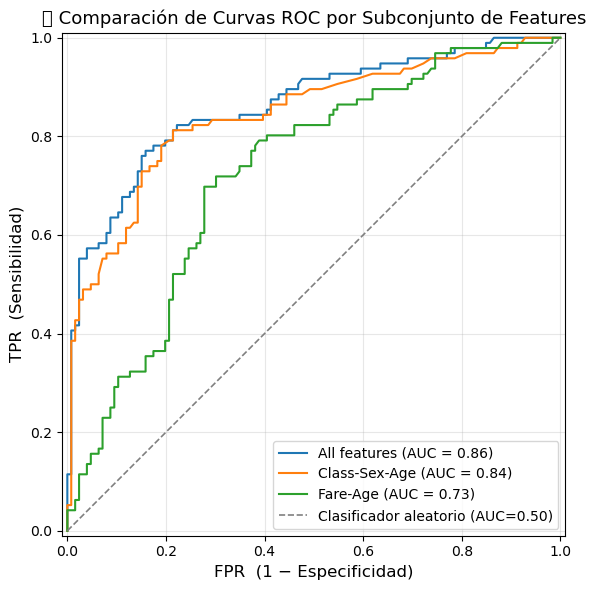


📐 AUC resumen:
  M1 (todas features):  0.8621
  M2 (Pclass+Sex+Age):  0.8428
  M3 (Fare+Age):        0.7272


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# Curva ROC de los tres modelos (con AUC en la leyenda automáticamente)
RocCurveDisplay.from_estimator(model1, X1_test, y_test, ax=ax,
                                name='All features')
RocCurveDisplay.from_estimator(model2, X2_test, y_test, ax=ax,
                                name='Class-Sex-Age')
RocCurveDisplay.from_estimator(model3, X3_test, y_test, ax=ax,
                                name='Fare-Age')

# Línea de clasificador aleatorio
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.2,
        label='Clasificador aleatorio (AUC=0.50)')

ax.set_xlabel('FPR  (1 − Especificidad)', fontsize=12)
ax.set_ylabel('TPR  (Sensibilidad)', fontsize=12)
ax.set_title('Comparación de Curvas ROC por Subconjunto de Features', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n📐 AUC resumen:')
print(f'  M1 (todas features):  {auc1:.4f}')
print(f'  M2 (Pclass+Sex+Age):  {auc2:.4f}')
print(f'  M3 (Fare+Age):        {auc3:.4f}')

## 🔬 Paso 5: Análisis Detallado de las Curvas

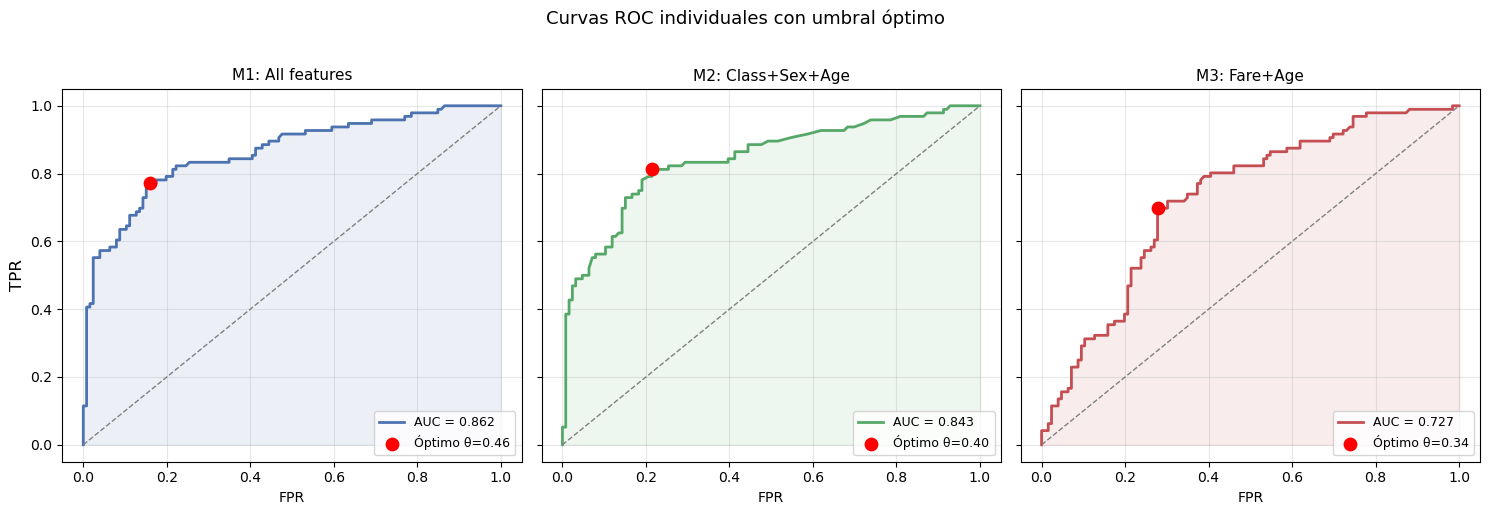


🎯 Umbrales óptimos (min distancia al punto ideal (0,1)):
  M1: θ=0.460  → FPR=0.159, TPR=0.771
  M2: θ=0.398  → FPR=0.214, TPR=0.812
  M3: θ=0.335  → FPR=0.278, TPR=0.698


In [7]:
from sklearn.metrics import roc_curve

# Calcular puntos de la curva para análisis
fpr1, tpr1, thr1 = roc_curve(y_test, model1.predict_proba(X1_test)[:, 1])
fpr2, tpr2, thr2 = roc_curve(y_test, model2.predict_proba(X2_test)[:, 1])
fpr3, tpr3, thr3 = roc_curve(y_test, model3.predict_proba(X3_test)[:, 1])

# Umbral óptimo de cada modelo (min distancia al (0,1))
def umbral_optimo(fpr, tpr, thresholds):
    dist = np.sqrt(fpr**2 + (1 - tpr)**2)
    idx  = np.argmin(dist)
    return thresholds[idx], fpr[idx], tpr[idx]

u1, f1_opt, t1_opt = umbral_optimo(fpr1, tpr1, thr1)
u2, f2_opt, t2_opt = umbral_optimo(fpr2, tpr2, thr2)
u3, f3_opt, t3_opt = umbral_optimo(fpr3, tpr3, thr3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

configs = [
    ('M1: All features',   fpr1, tpr1, auc1, u1, f1_opt, t1_opt, '#4C72B0'),
    ('M2: Class+Sex+Age',  fpr2, tpr2, auc2, u2, f2_opt, t2_opt, '#55A868'),
    ('M3: Fare+Age',       fpr3, tpr3, auc3, u3, f3_opt, t3_opt, '#C44E52'),
]

for ax, (nombre, fpr, tpr, auc, u_opt, f_opt, t_opt, color) in zip(axes, configs):
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'AUC = {auc:.3f}')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    ax.scatter([f_opt], [t_opt], color='red', zorder=5, s=80,
               label=f'Óptimo θ={u_opt:.2f}')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('FPR')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('TPR', fontsize=12)
fig.suptitle('Curvas ROC individuales con umbral óptimo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n🎯 Umbrales óptimos (min distancia al punto ideal (0,1)):')
print(f'  M1: θ={u1:.3f}  → FPR={f1_opt:.3f}, TPR={t1_opt:.3f}')
print(f'  M2: θ={u2:.3f}  → FPR={f2_opt:.3f}, TPR={t2_opt:.3f}')
print(f'  M3: θ={u3:.3f}  → FPR={f3_opt:.3f}, TPR={t3_opt:.3f}')

## 📊 Paso 6: Tabla Comparativa Final

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metricas_en_umbral(model, X_test, y_test, umbral):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred_u = (y_prob >= umbral).astype(int)
    y_pred_d = model.predict(X_test)  # umbral default 0.5
    return {
        'Accuracy (0.50)':  accuracy_score(y_test, y_pred_d),
        'Precision (0.50)': precision_score(y_test, y_pred_d, zero_division=0),
        'Recall (0.50)':    recall_score(y_test, y_pred_d, zero_division=0),
        'F1 (0.50)':        f1_score(y_test, y_pred_d, zero_division=0),
        'AUC':              roc_auc_score(y_test, y_prob),
    }

m1_r = metricas_en_umbral(model1, X1_test, y_test, u1)
m2_r = metricas_en_umbral(model2, X2_test, y_test, u2)
m3_r = metricas_en_umbral(model3, X3_test, y_test, u3)

tabla = pd.DataFrame({
    'M1: All features':  m1_r,
    'M2: Class+Sex+Age': m2_r,
    'M3: Fare+Age':      m3_r,
}).T.round(4)

print('📋 Tabla comparativa final:')
print(tabla.to_string())

print('\n' + '─'*55)
print('🏆 Ganador por métrica:')
for col in tabla.columns:
    ganador = tabla[col].idxmax()
    val = tabla.loc[ganador, col]
    print(f'  {col:<20}: {ganador} ({val:.4f})')

📋 Tabla comparativa final:
                   Accuracy (0.50)  Precision (0.50)  Recall (0.50)  F1 (0.50)     AUC
M1: All features            0.7883            0.7882         0.6979     0.7403  0.8621
M2: Class+Sex+Age           0.7883            0.7816         0.7083     0.7432  0.8428
M3: Fare+Age                0.6216            0.6875         0.2292     0.3438  0.7272

───────────────────────────────────────────────────────
🏆 Ganador por métrica:
  Accuracy (0.50)     : M1: All features (0.7883)
  Precision (0.50)    : M1: All features (0.7882)
  Recall (0.50)       : M2: Class+Sex+Age (0.7083)
  F1 (0.50)           : M2: Class+Sex+Age (0.7432)
  AUC                 : M1: All features (0.8621)


## 🏁 Conclusiones

En este notebook aprendimos:

1. 📉 Las **Curvas ROC superpuestas** permiten comparar visualmente múltiples modelos de forma directa e intuitiva.
2. 📐 El **AUC** es una métrica robusta para comparar modelos independientemente del umbral elegido.
3. ⚠️ Para comparar modelos con ROC/AUC, es imprescindible usar el **mismo conjunto de test** (mismo split).
4. 🎛️ `RocCurveDisplay.from_estimator()` simplifica drásticamente el código: calcula probabilidades, ROC y AUC en una sola llamada.
5. 🤔 En el Titanic, el sexo (`male`) es una variable altamente predictiva: M2 (Pclass + Sex + Age) logra un AUC muy cercano a M1 (todas las features), siendo un modelo más simple.

---

### 🎓 ¡Ciclo completo de Evaluación de Modelos completado!

| Notebook | Tema |
|----------|------|
| 17 | Métricas: Accuracy, Precision, Recall, F1 y Matriz de Confusión |
| 18 | Sensibilidad, Especificidad y Umbral de Decisión |
| 19 | Curva ROC y AUC |
| 20 | Validación Cruzada K-Fold |
| 21 | Comparación de modelos con K-Fold y métricas |
| **22** | **Comparación de modelos con Curvas ROC y AUC** |

---

## 📚 Referencias

- Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
- Hand, D. J., & Till, R. J. (2001). [A Simple Generalisation of the Area Under the ROC Curve for Multiple Class Classification Problems](https://link.springer.com/article/10.1023/A:1010920819831). *Machine Learning*, 45, 171–186.
- Scikit-learn: [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
- Géron, A. (2019). *Hands-On Machine Learning*, Cap. 3. O'Reilly.